In [1]:
"""
Fair Clustering Dataset Utilities
==================================
Two dataset sources for evaluating fair multi-attribute clustering:
  1. Synthetic data  — 3 protected attributes: Race(3) × Sex(2) × EducationTier(2) = 12 groups
  2. Folktables ACS  — 3 protected attributes: same structure, genuinely continuous features

The number of protected attributes is controlled by `n_protected_attrs` (2 or 3).
Using 3 attributes directly stresses balance constraints (more groups = harder feasibility)
and lets you study how group count affects G-PoF — directly relevant to your thesis.

Clustering features are always spatial/socioeconomic — never the protected attributes.
"""


import seaborn as sns
import geopandas as gpd
from folktables import ACSDataSource
import time

import matplotlib.patches as mpatches
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
import pandas as pd
import gc

In [5]:
#pip install pandas geopandas folktables

In [6]:
#STATE_FIPS = {
#    'AL': '01', 'AK': '02', 'AZ': '04', 'AR': '05', 'CA': '06', 'CO': '08',
#    'CT': '09', 'DE': '10', 'FL': '12', 'GA': '13', 'HI': '15', 'ID': '16',
#    'IL': '17', 'IN': '18', 'IA': '19', 'KS': '20', 'KY': '21', 'LA': '22',
#    'ME': '23', 'MD': '24', 'MA': '25', 'MI': '26', 'MN': '27', 'MS': '28',
#    'MO': '29', 'MT': '30', 'NE': '31', 'NV': '32', 'NH': '33', 'NJ': '34',
#    'NM': '35', 'NY': '36', 'NC': '37', 'ND': '38', 'OH': '39', 'OK': '40',
#    'OR': '41', 'PA': '42', 'RI': '44', 'SC': '45', 'SD': '46', 'TN': '47',
#    'TX': '48', 'UT': '49', 'VT': '50', 'VA': '51', 'WA': '53', 'WV': '54',
#    'WI': '55', 'WY': '56'
#}
#
#
#survey_year = "2022"
#data_source = ACSDataSource(survey_year=survey_year, horizon="1-Year", survey="person")
#
#all_states_data = []
#
#for state, fips in STATE_FIPS.items():
#    print(f"\n--- Processing {state} (FIPS: {fips}) ---")
#
#    try:
#        df_acs = data_source.get_data(states=[state], download=True)
#        print(f"  Loaded ACS Data: {len(df_acs)} rows")
#
#        shapefile_url = f"https://www2.census.gov/geo/tiger/TIGER2022/PUMA/tl_2022_{fips}_puma20.zip"
#        print(f"  Downloading shapefile...")
#        gdf_puma = gpd.read_file(shapefile_url)
#
#        gdf_puma_projected = gdf_puma.to_crs(epsg=3857)
#        centroids = gdf_puma_projected.geometry.centroid.to_crs(epsg=4326)
#
#        gdf_puma['Longitude'] = centroids.x
#        gdf_puma['Latitude'] = centroids.y
#
#        gdf_puma['PUMA_ID'] = gdf_puma['PUMACE20'].astype(int)
#        df_acs['PUMA_ID'] = df_acs['PUMA'].astype(int)
#
#        puma_coords = gdf_puma[['PUMA_ID', 'Latitude', 'Longitude']]
#
#        df_merged = df_acs.merge(puma_coords, on='PUMA_ID', how='inner')
#
#        df_merged['RACE'] = df_merged['RAC1P']
#
#        all_states_data.append(df_merged)
#        print(f"  Successfully merged {len(df_merged)} rows for {state}.")
#
#        time.sleep(1)
#
#    except Exception as e:
#        print(f"  Error processing {state}: {e}")
#
#print("\nConcatenating all states...")
#final_us_dataset = pd.concat(all_states_data, ignore_index=True)
#
#columns_to_show = ['AGEP', 'SEX', 'RACE', 'PINCP', 'PUMA_ID', 'Latitude', 'Longitude']
#print(f"\n=== FINAL DATASET READY: {len(final_us_dataset)} total rows ===")
#print(final_us_dataset[columns_to_show].head())
#print("\nDataset Info:")
#print(final_us_dataset.info())
#
#final_us_dataset.to_csv("us_census_puma_data.csv", index=False)

In [2]:
cols_to_use = ['Longitude', 'Latitude', 'PINCP', 'AGEP', 'SEX', 'RAC1P']

RAC1P_LABELS = {
    1: 'White',
    2: 'Black or African American',
    3: 'American Indian',
    4: 'Alaska Native',
    5: 'American Indian and Alaska Native Tribes',
    6: 'Asian',
    7: 'Native Hawaiian and Other Pacific Islander',
    8: 'Some Other Race',
    9: 'Two or More Races'
}

dtypes = {
    'Longitude': 'float32',
    'Latitude': 'float32',
    'PINCP': 'float32',
    'AGEP': 'Int16',
    'SEX': 'Int8',
    'RAC1P': 'Int16'
}
df = pd.read_csv(
    "us_census_puma_data.csv",
    usecols=cols_to_use,
    dtype=dtypes,
    engine='pyarrow'
)
print(f"{len(df):,} rows")
print(df.info())




df['Longitude'] = pd.to_numeric(df['Longitude'], downcast='float')
df['Latitude']  = pd.to_numeric(df['Latitude'],  downcast='float')
df['PINCP']     = pd.to_numeric(df['PINCP'],      downcast='float')
df['AGEP']      = pd.to_numeric(df['AGEP'],       downcast='integer')
df['SEX']       = df['SEX'].astype('int8')
df['RACE']      = pd.to_numeric(df['RAC1P'],       downcast='integer')
BIN_EDGES   = [0, 25, 45, 65, 98]
BIN_LABELS  = ['Youth (0–24)', 'Young Adult (25–44)', 'Adult (45–64)', 'Senior (65+)']
BIN_COLORS  = ['#B5D4F4', '#378ADD', '#185FA5', '#0C447C']
CUT_POINTS  = [25, 45, 65]

3,366,660 rows
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3366660 entries, 0 to 3366659
Data columns (total 6 columns):
 #   Column     Dtype  
---  ------     -----  
 0   Longitude  float32
 1   Latitude   float32
 2   PINCP      float32
 3   AGEP       Int16  
 4   SEX        Int8   
 5   RAC1P      Int16  
dtypes: Int16(2), Int8(1), float32(3)
memory usage: 64.2 MB
None


In [ ]:
df_sample = df.sample(frac=0.05, random_state=42)

plt.figure(figsize=(10, 6), facecolor='white')
ax = plt.gca()
ax.set_facecolor('white')
plt.scatter(
    df_sample['Longitude'],
    df_sample['Latitude'],
    color='black',
    alpha=0.3,
    s=1.5,
    linewidths=0
)
plt.xlabel('Longitude', color='black')
plt.ylabel('Latitude', color='black')
plt.tick_params(colors='black')
plt.tight_layout()
plt.savefig('1_spatial_scatter.png', dpi=150, bbox_inches='tight')
plt.close()
print("Saved 1_spatial_scatter.png")

plt.figure(figsize=(10, 6), facecolor='white')
ax = plt.gca()
ax.set_facecolor('white')
hb = plt.hexbin(
    df['Longitude'],
    df['Latitude'],
    gridsize=70,
    cmap='Blues',
    mincnt=1
)
plt.colorbar(hb, label='Population Density (Count)')
plt.xlabel('Longitude', color='black')
plt.ylabel('Latitude', color='black')
plt.tick_params(colors='black')
plt.tight_layout()
plt.savefig('2_spatial_hexbin.png', dpi=150, bbox_inches='tight')
plt.close()
print("Saved 2_spatial_hexbin.png")

In [ ]:
plt.figure(figsize=(10, 6), facecolor='white')
ax = plt.gca()
ax.set_facecolor('white')
capped_income = df['PINCP'].dropna().clip(lower=0, upper=200000)
plt.hist(capped_income, bins=50, color='steelblue', edgecolor='black', alpha=0.8)
plt.xlabel('Income ($)', color='black')
plt.ylabel('Frequency', color='black')
plt.tick_params(colors='black')
plt.tight_layout()
plt.savefig('3_income_capped.png', dpi=150, bbox_inches='tight')
plt.close()
print("Saved 3_income_capped.png")
del capped_income
gc.collect()

In [ ]:
plt.figure(figsize=(10, 6), facecolor='white')
ax = plt.gca()
ax.ticklabel_format(style='plain', axis='x')
ax.set_facecolor('white')
uncapped_income = df['PINCP'].dropna()
plt.hist(uncapped_income, bins=100, color='steelblue', edgecolor='black', alpha=0.8)
ax.xaxis.set_major_formatter(FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.xlabel('Income ($)', color='black')
plt.ylabel('Frequency', color='black')
plt.tick_params(colors='black')
plt.tight_layout()
plt.savefig('4_income_uncapped.png', dpi=150, bbox_inches='tight')
plt.close()
print("Saved 4_income_uncapped.png")
del uncapped_income
gc.collect()

In [ ]:
ages = df['AGEP'].dropna().astype(int)

fig, ax = plt.subplots(figsize=(11, 5), facecolor='white')
ax.set_facecolor('white')

age_counts = ages.value_counts().sort_index()
age_values = age_counts.index.to_numpy()
age_freqs  = age_counts.values

bar_colors = []
for age in age_values:
    for i in range(len(BIN_EDGES) - 1):
        if BIN_EDGES[i] <= age < BIN_EDGES[i + 1]:
            bar_colors.append(BIN_COLORS[i])
            break

ax.bar(age_values, age_freqs, color=bar_colors,
       width=1.0, edgecolor='none', align='center')

ymax = ax.get_ylim()[1]
for cut in CUT_POINTS:
    ax.axvline(cut - 0.5, color='#555555', linewidth=1.2,
               linestyle='--', alpha=0.6)
    ax.text(cut - 0.5, ymax * 0.98, str(cut),
            ha='center', va='top', fontsize=9,
            color='#555555')

patches = [mpatches.Patch(facecolor=BIN_COLORS[i], label=BIN_LABELS[i])
           for i in range(len(BIN_LABELS))]

ax.legend(handles=patches, loc='upper center',
          bbox_to_anchor=(0.5, -0.13),
          fontsize=9, frameon=False, ncol=4)

ax.set_xlabel('Age (years)', color='black', fontsize=11)
ax.set_ylabel('Frequency', color='black', fontsize=11)
ax.tick_params(colors='black')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.set_xlim(-1, 98)
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
fig.subplots_adjust(bottom=0.18)
plt.savefig('5_age_distribution_binned.png', dpi=150, bbox_inches='tight')
plt.close()
print("Saved 5_age_distribution_binned.png")

In [ ]:
plt.figure(figsize=(10, 6), facecolor='white')
ax = plt.gca()
ax.set_facecolor('white')
sex_counts = df['SEX'].value_counts().sort_index()
sex_counts.index = ['Male (1)', 'Female (2)']
plt.bar(sex_counts.index, sex_counts.values, color='steelblue', edgecolor='black', alpha=0.8)
plt.ylabel('Count', color='black')
plt.tick_params(colors='black')
plt.tight_layout()
plt.savefig('6_sex_distribution.png', dpi=150, bbox_inches='tight')
plt.close()
print("Saved 6_sex_distribution.png")

In [11]:
plt.figure(figsize=(10, 6), facecolor='white')
ax = plt.gca()
ax.set_facecolor('white')
race_counts = df['RACE'].value_counts().sort_index()
race_counts.index = race_counts.index.map(RAC1P_LABELS).fillna('Unknown')
plt.bar(race_counts.index, race_counts.values,
        color='steelblue', edgecolor='black', alpha=0.8)
plt.ylabel('Count', color='black')
plt.xticks(rotation=45, ha='right')
plt.tick_params(colors='black')
plt.tight_layout()
plt.savefig('7_race_distribution.png', dpi=150, bbox_inches='tight')
plt.close()
print("Saved 7_race_distribution.png")

print("\nAll plots saved successfully.")

Loading data...
Loaded 3,366,660 rows
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3366660 entries, 0 to 3366659
Data columns (total 6 columns):
 #   Column     Dtype  
---  ------     -----  
 0   Longitude  float32
 1   Latitude   float32
 2   PINCP      float32
 3   AGEP       Int16  
 4   SEX        Int8   
 5   RAC1P      Int16  
dtypes: Int16(2), Int8(1), float32(3)
memory usage: 64.2 MB
None
Saved 1_spatial_scatter.png
Saved 2_spatial_hexbin.png
Saved 3_income_capped.png
Saved 4_income_uncapped.png
Saved 5_age_distribution_binned.png
Saved 6_sex_distribution.png
Saved 7_race_distribution.png

All plots saved successfully.


In [3]:
df_sample['RACE_MACRO'] = df_sample['RACE'].apply(lambda x: 'White' if x == 1 else ('Black' if x == 2 else 'Other'))
df['RACE_MACRO'] = df['RACE'].apply(lambda x: 'White' if x == 1 else ('Black' if x == 2 else 'Other'))


In [4]:
plt.figure(figsize=(10, 6), facecolor='white')
ax = plt.gca()
ax.set_facecolor('white')
colors = {'White': 'steelblue', 'Black': 'darkorange', 'Other': 'forestgreen'}
for r in ['White', 'Black', 'Other']:
    subset = df_sample[df_sample['RACE_MACRO'] == r]
    plt.scatter(subset['Longitude'], subset['Latitude'], c=colors[r], label=r, alpha=0.4, s=1.5, linewidths=0)
plt.xlabel('Longitude', color='black')
plt.ylabel('Latitude', color='black')
plt.legend(loc='lower right', markerscale=10)
plt.tick_params(colors='black')
plt.tight_layout()
plt.savefig('8_spatial_by_race.png', dpi=150, bbox_inches='tight')

plt.close()
print("Saved 8_spatial_by_race.png")

Saved 8_spatial_by_race.png


In [5]:

def plot_colored_histogram(data, cut_points, labels, colors, title, filename):
    fig, ax = plt.subplots(figsize=(11, 5), facecolor='white')
    ax.set_facecolor('white')

    counts, bins, patches = ax.hist(data, bins=100, edgecolor='none')

    for patch, left_edge, right_edge in zip(patches, bins[:-1], bins[1:]):
        center = (left_edge + right_edge) / 2
        color_idx = 0
        for i, cut in enumerate(cut_points):
            if center >= cut:
                color_idx = i + 1
        color_idx = min(color_idx, len(colors) - 1)
        patch.set_facecolor(colors[color_idx])

    ymax = ax.get_ylim()[1]
    for cut in cut_points:

        if cut <= 200000:
            ax.axvline(cut, color='#555555', linewidth=1.2, linestyle='--', alpha=0.8)
            bbox_props = dict(boxstyle="round,pad=0.3", fc="white", ec="none", alpha=0.7)
            ax.text(cut + 2000, ymax * 0.95, f'${int(cut):,}',
                    ha='left', va='top', fontsize=9, color='#333333', rotation=90, bbox=bbox_props)

    legend_patches = [mpatches.Patch(facecolor=colors[i], label=labels[i]) for i in range(len(labels))]
    ax.legend(handles=legend_patches, loc='upper center', bbox_to_anchor=(0.5, -0.15),
              fontsize=10, frameon=False, ncol=len(labels))

    ax.set_xlabel('Income ($)', color='black', fontsize=11)
    ax.set_ylabel('Frequency', color='black', fontsize=11)
    ax.set_title(title, fontsize=12, pad=15)
    ax.tick_params(colors='black')
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'))
    ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'))
    ax.set_xlim(0, 202000)
    ax.spines[['top', 'right']].set_visible(False)

    plt.tight_layout()
    fig.subplots_adjust(bottom=0.22)
    plt.savefig(filename, dpi=150, bbox_inches='tight')
    plt.show()
    plt.close()
    print(f"Saved {filename}")

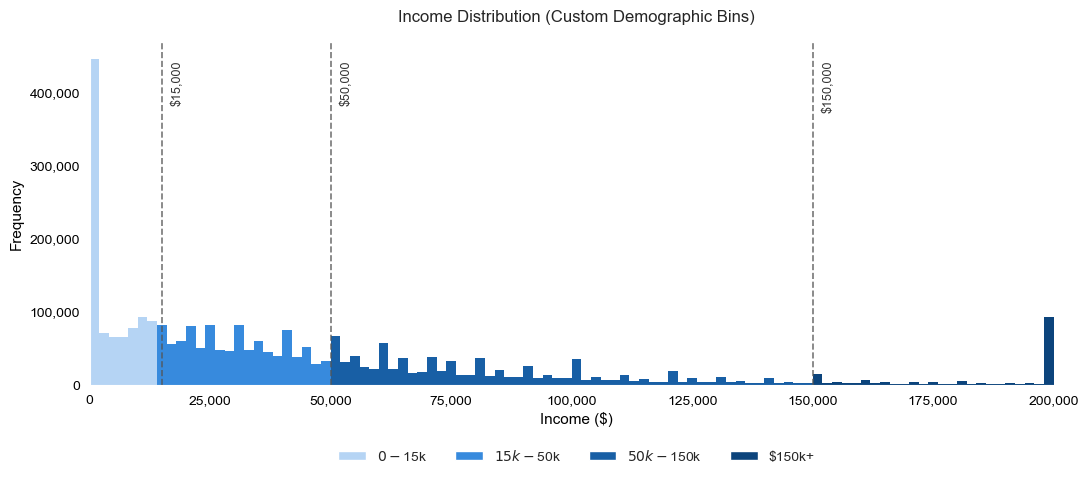

Saved 3a_income_custom_bins.png


In [6]:
CUSTOM_CUTS = [15000, 50000, 150000]
CUSTOM_LABELS = ['$0 - $15k', '$15k - $50k', '$50k - $150k', '$150k+']
CUSTOM_COLORS = ['#B5D4F4', '#378ADD', '#185FA5', '#0C447C']

capped_income = df['PINCP'].dropna().clip(lower=0, upper=200000)

plot_colored_histogram(
    data=capped_income,
    cut_points=CUSTOM_CUTS,
    labels=CUSTOM_LABELS,
    colors=CUSTOM_COLORS,
    title='Income Distribution (Custom Demographic Bins)',
    filename='data-analysis/3a_income_custom_bins.png'
)

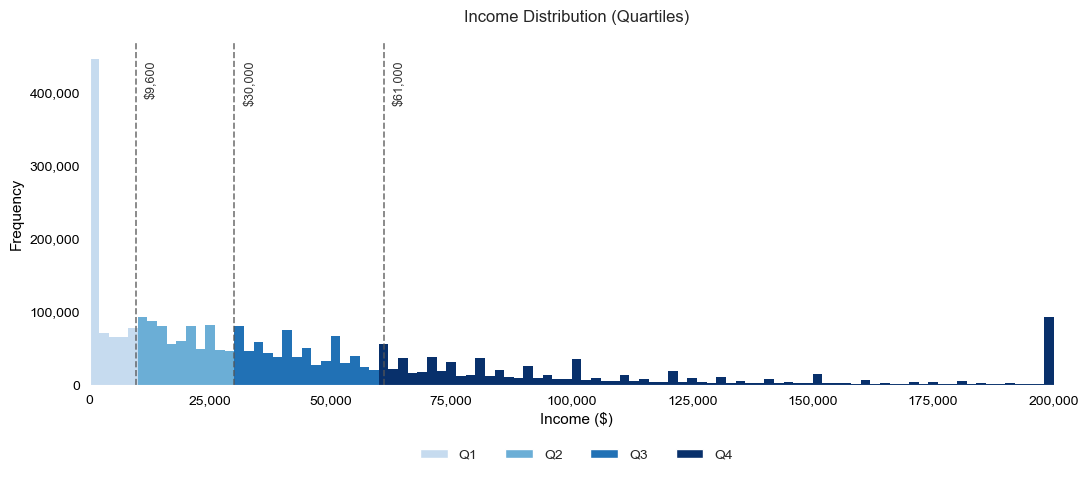

Saved 3b_income_quartiles.png


In [7]:
q_cuts = df['PINCP'].quantile([0.25, 0.5, 0.75]).values
Q_LABELS = ['Q1', 'Q2', 'Q3', 'Q4']
Q_COLORS = ['#C6DBEF', '#6BAED6', '#2171B5', '#08306B']

plot_colored_histogram(
    data=capped_income,
    cut_points=q_cuts,
    labels=Q_LABELS,
    colors=Q_COLORS,
    title='Income Distribution (Quartiles)',
    filename='data-analysis/3b_income_quartiles.png'
)

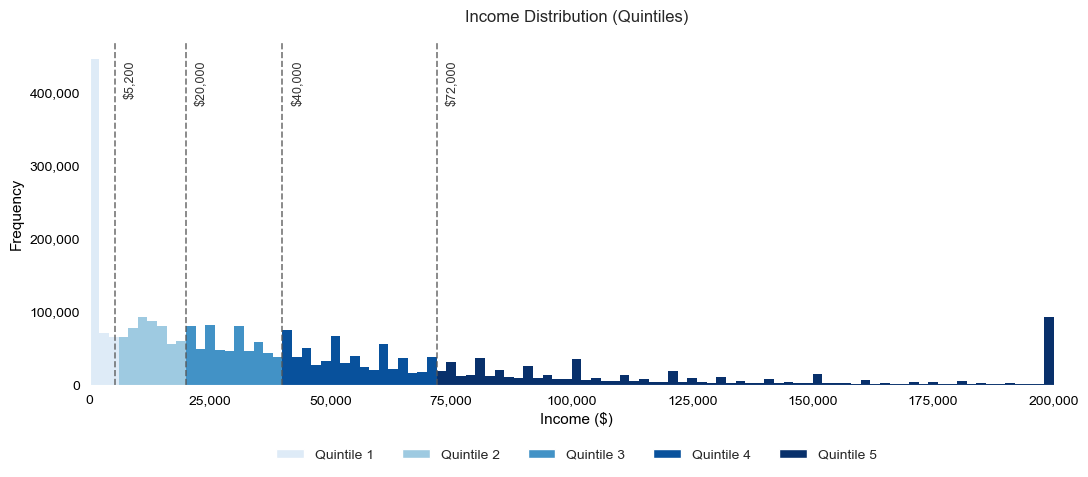

Saved 3c_income_quintiles.png


In [8]:
quint_cuts = df['PINCP'].quantile([0.2, 0.4, 0.6, 0.8]).values
QUINT_LABELS = ['Quintile 1', 'Quintile 2', 'Quintile 3', 'Quintile 4', 'Quintile 5']
QUINT_COLORS = ['#DEEBF7', '#9ECAE1', '#4292C6', '#08519C', '#08306B']

plot_colored_histogram(
    data=capped_income,
    cut_points=quint_cuts,
    labels=QUINT_LABELS,
    colors=QUINT_COLORS,
    title='Income Distribution (Quintiles)',
    filename='data-analysis/3c_income_quintiles.png'
)